# 01 — Conversion Explorer

Convert quantum algorithms to ZX diagrams at multiple simplification levels.
Build intuition for how ZX rewrites reshape algorithmic structure.

In [1]:
import pandas as pd
import pyzx as zx
import matplotlib.pyplot as plt

from zx_motifs.algorithms.registry import REGISTRY
from zx_motifs.pipeline.converter import convert_at_all_levels
from zx_motifs.pipeline.featurizer import pyzx_to_networkx, compute_graph_features

## Batch Conversion

Convert every algorithm in the registry at multiple qubit counts.

In [2]:
all_snapshots = []
for entry in REGISTRY:
    min_q, max_q = entry.qubit_range
    for n in range(min_q, min(max_q + 1, 6)):  # Cap at 5 qubits for exploration
        try:
            qc = entry.generator(n_qubits=n)
            snaps = convert_at_all_levels(qc, f"{entry.name}_q{n}")
            all_snapshots.extend(snaps)
            print(f"  {entry.name} (n={n}): {len(snaps)} snapshots")
        except Exception as e:
            print(f"  {entry.name} (n={n}): FAILED — {e}")

print(f"\nTotal snapshots: {len(all_snapshots)}")

  bell_state (n=2): 6 snapshots
  bell_state (n=3): 6 snapshots
  bell_state (n=4): 6 snapshots
  bell_state (n=5): 6 snapshots
  ghz_state (n=3): 6 snapshots
  ghz_state (n=4): 6 snapshots
  ghz_state (n=5): 6 snapshots
  teleportation (n=3): 6 snapshots
  qft (n=2): 6 snapshots
  qft (n=3): 6 snapshots
  qft (n=4): 6 snapshots
  qft (n=5): 6 snapshots
  grover (n=3): 6 snapshots
  grover (n=4): 6 snapshots
  grover (n=5): 6 snapshots
  bernstein_vazirani (n=3): 6 snapshots
  bernstein_vazirani (n=4): 6 snapshots
  bernstein_vazirani (n=5): 6 snapshots
  deutsch_jozsa (n=2): 6 snapshots
  deutsch_jozsa (n=3): 6 snapshots
  deutsch_jozsa (n=4): 6 snapshots
  deutsch_jozsa (n=5): 6 snapshots
  phase_estimation (n=4): 6 snapshots
  phase_estimation (n=5): 6 snapshots
  qaoa_maxcut (n=3): 6 snapshots
  qaoa_maxcut (n=4): 6 snapshots
  qaoa_maxcut (n=5): 6 snapshots
  vqe_uccsd (n=4): 6 snapshots
  hw_efficient_ansatz (n=3): 6 snapshots
  hw_efficient_ansatz (n=4): 6 snapshots
  hw_efficie

## Summary Statistics

In [3]:
rows = [s.to_dict() for s in all_snapshots]
df = pd.DataFrame(rows)
print(df.groupby("level")[["vertices", "edges", "t_gates"]].mean().round(1))

                 vertices  edges  t_gates
level                                    
clifford_simp        26.2   36.3      2.6
full_reduce          23.2   31.5      2.2
interior_cliff       27.0   34.3      2.7
raw                  47.9   53.8      3.2
spider_fused         36.1   42.0      3.0
teleport_reduce      47.9   53.8      2.6


## Simplification Cascade Visualization

Pick one algorithm and visualize how each simplification level transforms it.

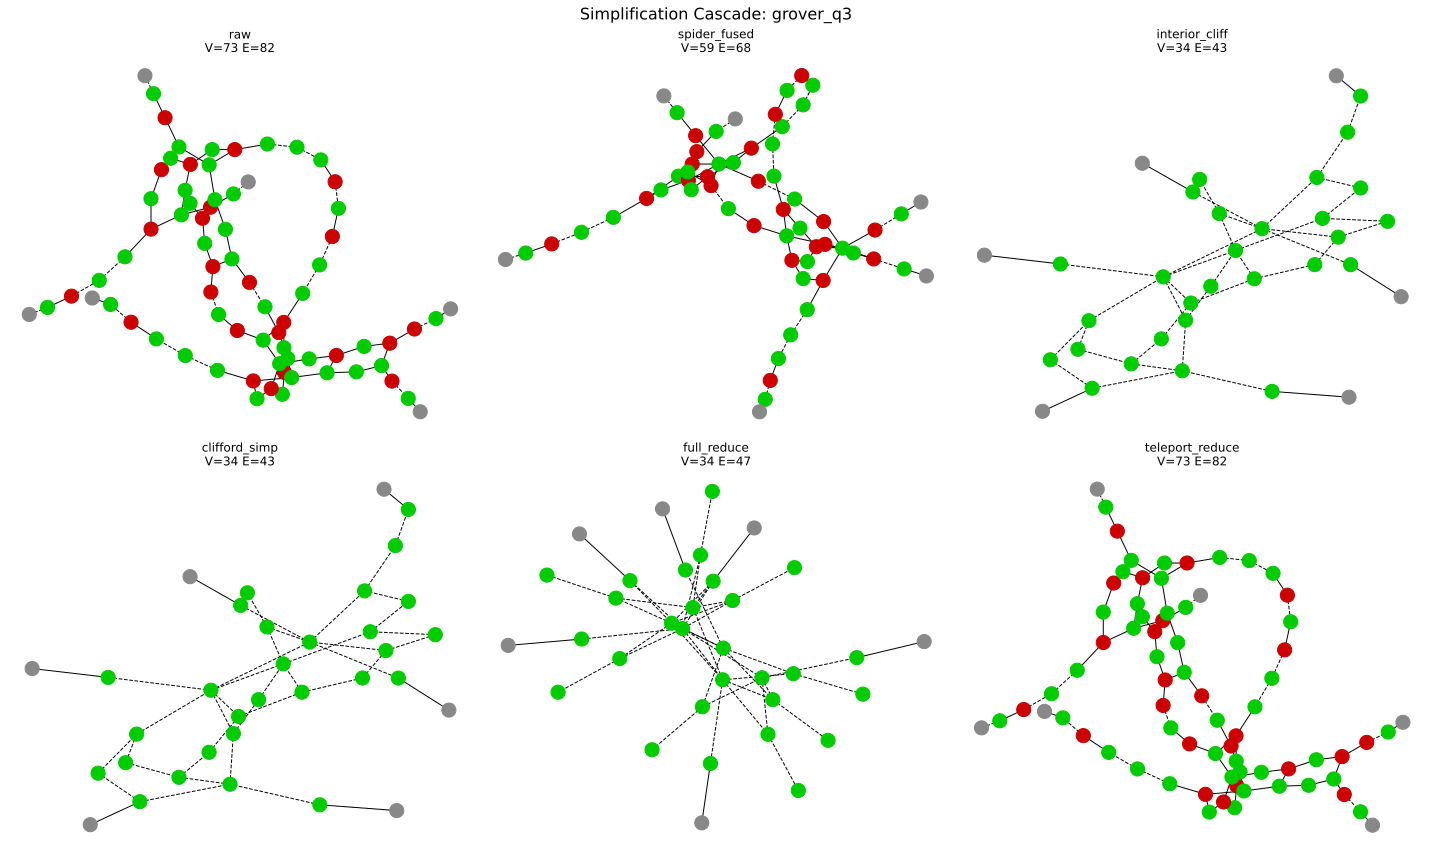

In [4]:
from zx_motifs.pipeline.featurizer import pyzx_to_networkx

target_algo = "grover_q3"
target_snaps = [s for s in all_snapshots if s.algorithm_name == target_algo]

if target_snaps:
    import networkx as nx

    color_map = {"Z": "#00cc00", "X": "#cc0000", "H_BOX": "#cccc00", "BOUNDARY": "#888888"}

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    for ax, snap in zip(axes.flat, target_snaps):
        ax.set_title(f"{snap.level.value}\nV={snap.num_vertices} E={snap.num_edges}")

        nxg = pyzx_to_networkx(snap.graph, coarsen_phases=True)
        pos = nx.spring_layout(nxg, seed=42)
        colors = [
            color_map.get(nxg.nodes[n].get("vertex_type", "?"), "#0000cc")
            for n in nxg.nodes()
        ]

        for u, v, d in nxg.edges(data=True):
            style = "dashed" if d.get("edge_type") == "HADAMARD" else "solid"
            nx.draw_networkx_edges(nxg, pos, edgelist=[(u, v)], style=style, ax=ax)

        nx.draw_networkx_nodes(nxg, pos, node_color=colors, node_size=200, ax=ax)
        ax.axis("off")

    plt.suptitle(f"Simplification Cascade: {target_algo}", fontsize=16)
    plt.tight_layout()
    plt.savefig("simplification_cascade.png", dpi=150)
    plt.show()
else:
    print(f"Algorithm '{target_algo}' not found in snapshots.")

## Feature Extraction & Clustering

In [5]:
# Convert all snapshots to NetworkX and compute features
feature_rows = []
nx_graphs = {}  # (algo_name, level) -> nx.Graph

for snap in all_snapshots:
    nxg = pyzx_to_networkx(snap.graph, coarsen_phases=True)
    key = (snap.algorithm_name, snap.level.value)
    nx_graphs[key] = nxg

    feats = compute_graph_features(nxg)
    feats["algorithm"] = snap.algorithm_name
    feats["level"] = snap.level.value
    feature_rows.append(feats)

feat_df = pd.DataFrame(feature_rows)
print(feat_df[["algorithm", "level", "n_nodes", "n_edges",
               "hadamard_ratio", "avg_degree"]].head(20).to_string())

        algorithm            level  n_nodes  n_edges  hadamard_ratio  avg_degree
0   bell_state_q2              raw        7        6        0.166667    1.714286
1   bell_state_q2     spider_fused        6        5        0.200000    1.666667
2   bell_state_q2   interior_cliff        6        5        0.800000    1.666667
3   bell_state_q2    clifford_simp        6        5        0.800000    1.666667
4   bell_state_q2      full_reduce        6        5        0.800000    1.666667
5   bell_state_q2  teleport_reduce        7        6        0.166667    1.714286
6   bell_state_q3              raw       11       10        0.100000    1.818182
7   bell_state_q3     spider_fused        9        8        0.125000    1.777778
8   bell_state_q3   interior_cliff        9        8        0.875000    1.777778
9   bell_state_q3    clifford_simp        9        8        0.875000    1.777778
10  bell_state_q3      full_reduce        9        8        0.875000    1.777778
11  bell_state_q3  teleport_

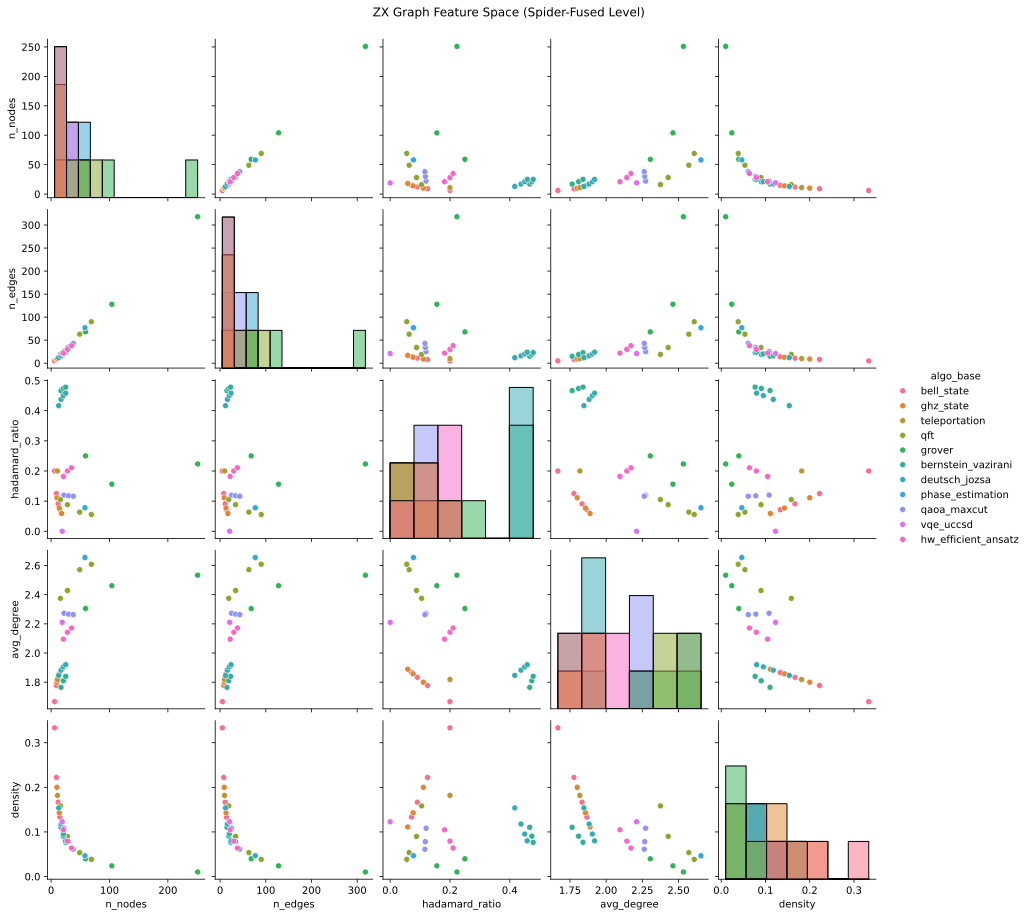

In [6]:
try:
    import seaborn as sns

    spider_df = feat_df[feat_df["level"] == "spider_fused"].copy()
    cluster_cols = ["n_nodes", "n_edges", "hadamard_ratio", "avg_degree", "density"]
    available_cols = [c for c in cluster_cols if c in spider_df.columns]

    if len(available_cols) >= 2:
        # Extract base algorithm name for hue
        spider_df["algo_base"] = spider_df["algorithm"].str.rsplit("_q", n=1).str[0]
        sns.pairplot(spider_df, vars=available_cols, hue="algo_base", diag_kind="hist")
        plt.suptitle("ZX Graph Feature Space (Spider-Fused Level)", y=1.02)
        plt.savefig("feature_clustering.png", dpi=150)
        plt.show()
except ImportError:
    print("Install seaborn for clustering visualization: pip install seaborn")

## Observation Log

Fill this in as you explore — building intuition is the goal.

```
OBSERVATION LOG:

1. [algo] at [level]: noticed [pattern]
   Example: "grover_q3 at spider_fused: the oracle and diffusion
   operator produce symmetric Z-spider clusters connected by
   Hadamard edges — the two clusters are near-identical up to phase"

2. ...
```